In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime
import matplotlib.dates as mdates

# Choose some nice levels
plt.rcParams["figure.figsize"] = [16, 9]
plt.rcParams["figure.autolayout"] = True

In [2]:
commits = pd.read_csv('../data/zephyr_commit_times.csv',names=["sha1", "author_date", "author_email", "committer_date", "committer_email"], header=0)

In [3]:
commits.author_date= pd.to_datetime(commits.author_date, utc=True)
commits.committer_date = pd.to_datetime(commits.committer_date, utc=True)
commits.committer_date.min()

Timestamp('2015-04-10 23:44:37+0000', tz='UTC')

In [4]:
resampled=commits.resample("M", on="author_date").count()
resampled

/tmp/ipykernel_6140/1036463746.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled=commits.resample("M", on="author_date").count()


,sha1,author_email,committer_date,committer_email
author_date,,,,
2014-12-31 00:00:00+00:00,4,4,4,4
2015-01-31 00:00:00+00:00,3,3,3,3
2015-02-28 00:00:00+00:00,11,11,11,11
2015-03-31 00:00:00+00:00,21,21,21,21
2015-04-30 00:00:00+00:00,474,474,474,474
...,...,...,...,...
2023-06-30 00:00:00+00:00,1179,1179,1179,1179
2023-07-31 00:00:00+00:00,1166,1166,1166,1166
2023-08-31 00:00:00+00:00,1188,1188,1188,1188


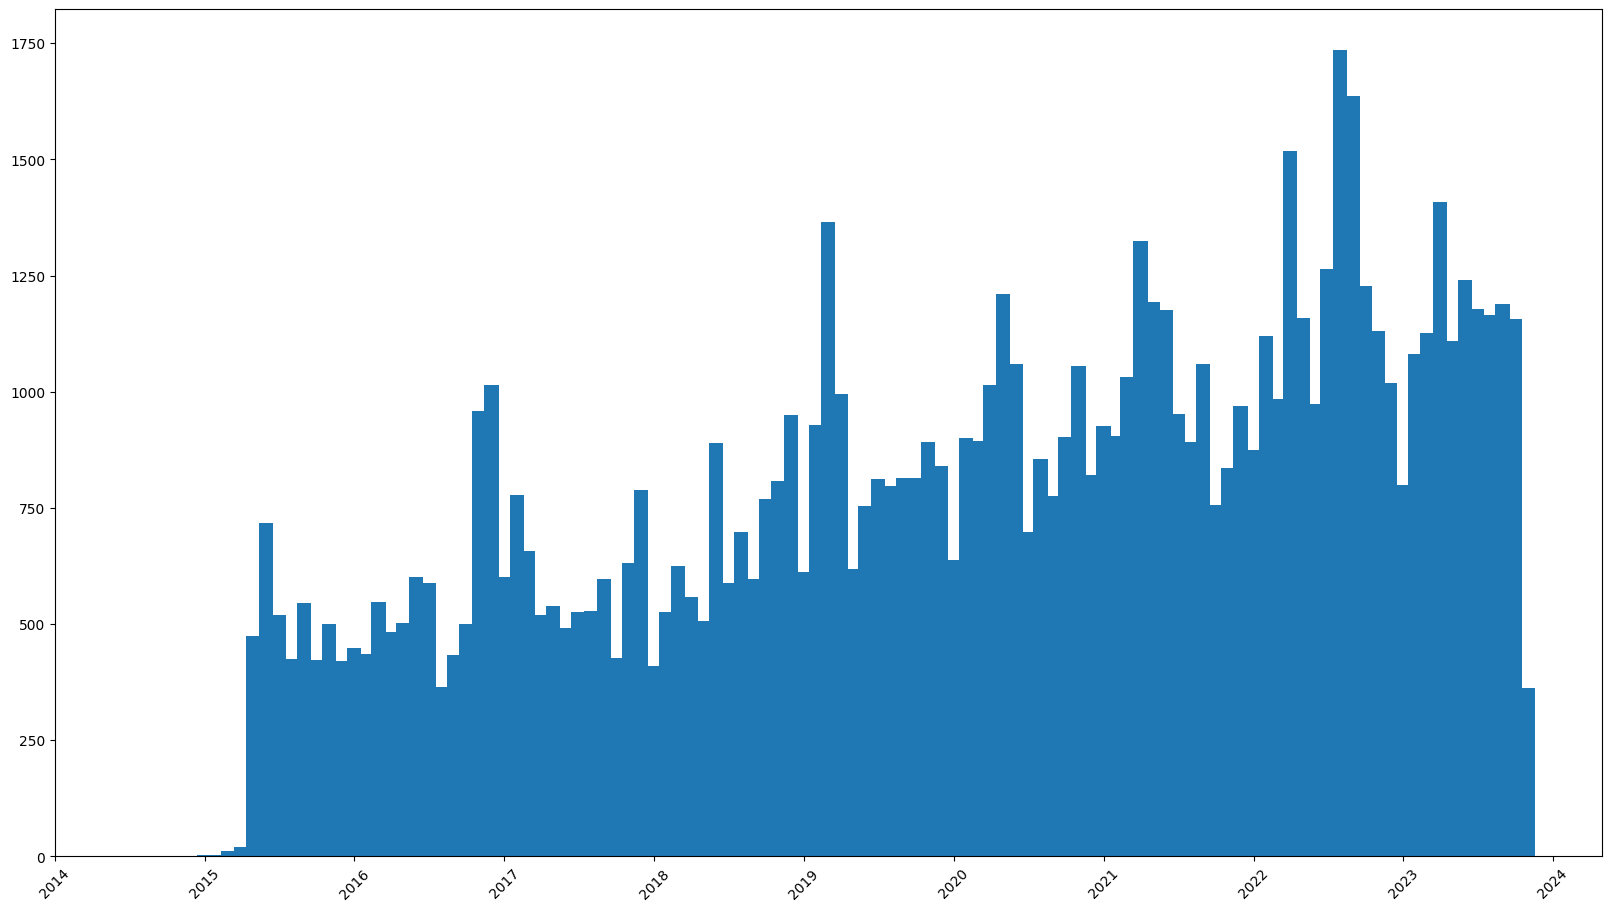

In [5]:
fig, ax = plt.subplots(figsize=(16,9), constrained_layout=True)
ax.bar(resampled.index, resampled['sha1'], width=35)
            
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(),rotation=45)
             
fig.savefig('../figures/zephyr-commits-per-month.svg', format='svg')     

In [6]:
activity_max = commits.filter(['committer_date'], axis=1).groupby(commits['author_email']).max().rename(columns={"committer_date":"max_author_date"})
activity_min = commits.filter(['committer_date'], axis=1).groupby(commits['author_email']).min().rename(columns={"committer_date":"min_author_date"})
activity_commits = commits.filter(['committer_date'], axis=1).groupby(commits['author_email']).count().rename(columns={'committer_date':'#commits'})
author_activity = pd.concat([activity_commits,activity_min, activity_max], axis=1, join='inner')
author_activity['span'] = author_activity['max_author_date'] - author_activity['min_author_date']
author_activity['span'].describe()

count                           2269
mean     275 days 14:45:44.107977084
std      466 days 09:49:40.011846744
min                  0 days 00:00:00
25%                  0 days 00:00:00
50%                 39 days 15:47:18
75%                361 days 23:42:40
max               3106 days 16:41:08
Name: span, dtype: object

In [7]:
# Top 50 longest active authors
veterans=author_activity.sort_values(by='#commits', ascending=False)
veterans.head(50)


,#commits,min_author_date,max_author_date,span
author_email,,,,
anas.nashif@intel.com,4992,2015-04-11 00:59:48+00:00,2023-10-12 17:40:56+00:00,3106 days 16:41:08
jukka.rissanen@linux.intel.com,2889,2016-02-06 01:14:14+00:00,2023-07-05 09:19:40+00:00,2706 days 08:05:26
kumar.gala@linaro.org,2494,2016-05-25 11:28:34+00:00,2021-12-08 22:50:27+00:00,2023 days 11:21:53
vich@nordicsemi.no,2009,2017-05-05 12:56:04+00:00,2023-10-12 06:48:54+00:00,2350 days 17:52:50
andrew.p.boie@intel.com,1924,2016-02-06 01:14:37+00:00,2021-07-31 00:16:47+00:00,2001 days 23:02:10
gerard.marull@nordicsemi.no,1870,2021-03-06 14:34:09+00:00,2023-08-24 11:20:21+00:00,900 days 20:46:12
johan.hedberg@intel.com,1752,2016-02-06 01:13:40+00:00,2023-10-14 08:59:13+00:00,2807 days 07:45:33
tomasz.bursztyka@linux.intel.com,1605,2016-02-06 01:13:48+00:00,2023-09-22 07:23:18+00:00,2785 days 06:09:30
erwan.gouriou@linaro.org,1509,2016-11-03 20:29:03+00:00,2023-06-13 13:11:19+00:00,2412 days 16:42:16


In [8]:
#Onetime Committer
veterans[veterans['span']==pd.Timedelta(0)].count()

#commits           878
min_author_date    878
max_author_date    878
span               878
dtype: int64

In [9]:
author_activity.sort_values(by='span', ascending=False)['span'].dt.days.to_numpy()

array([3106, 2807, 2806, ...,    0,    0,    0])

In [10]:
commits.filter(['committer_date'], axis=1).groupby(commits['author_email']).count().rename(columns={'committer_date':'#commits'})

,#commits
author_email,
119524428@qq.com,2
1391548050@qq.com,1
1415430544@qq.com,1
17674105+martinjaeger@users.noreply.github.com,4
279939902@qq.com,2
...,...
zide.chen@intel.com,11
zisarono@gmail.com,1
znfgnu@gmail.com,1
